In [3]:
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [95]:
df = pd.read_csv("/content/drive/MyDrive/multilayer-perceptron/data.csv")

In [96]:
df.columns = [
    "id",
    "diagnostic",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_largest",
    "texture_largest",
    "perimeter_largest",
    "area_largest",
    "smoothness_largest",
    "compactness_largest",
    "concavity_largest",
    "concave_points_largest",
    "symmetry_largest",
    "fractal_dimension_largest",
]

df.head(3)

,id,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [97]:
df = df.drop(['id'], axis=1)
df.head(3)

,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [98]:
df['diagnostic'] = df['diagnostic'].str.replace("B", "0")
df['diagnostic'] = df['diagnostic'].str.replace("M", "1")
df.loc[:,'diagnostic'] = pd.to_numeric(df['diagnostic'])
df.head(3)

,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [99]:
diagnostic_corr = df.corr()['diagnostic'].sort_values(ascending=False)
diagnostic_corr.head(10)

,diagnostic
diagnostic,1.000000
concave_points_largest,0.793181
perimeter_largest,0.782470
concave_points_mean,0.776369
radius_largest,0.775725
perimeter_mean,0.741887
area_largest,0.732925
radius_mean,0.729376
area_mean,0.708389
concavity_mean,0.695648


In [100]:
diagnostic_corr.tail(5)

,diagnostic
fractal_dimension_se,0.076068
texture_se,-0.007024
symmetry_se,-0.009170
fractal_dimension_mean,-0.018099
smoothness_se,-0.066629


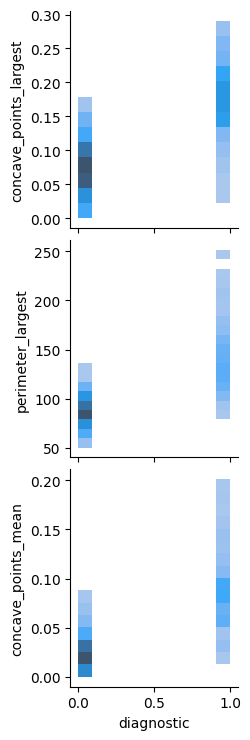

In [101]:
sns.pairplot(
    df,
    x_vars=['diagnostic'],
    y_vars=['concave_points_largest', 'perimeter_largest', 'concave_points_mean'],
    kind='hist'
)

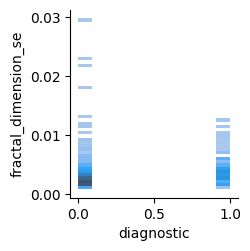

In [102]:
sns.pairplot(
    df,
    x_vars=['diagnostic'],
    y_vars=['fractal_dimension_se'],
    kind='hist'
)

In [103]:
df = df[['diagnostic',
        'concave_points_largest',
        'perimeter_largest',
        'concave_points_mean',
        'radius_largest',
        'perimeter_mean',
        'area_largest',
        'radius_mean',
        'area_mean',
        'concavity_mean']]

df.head(3)


,diagnostic,concave_points_largest,perimeter_largest,concave_points_mean,radius_largest,perimeter_mean,area_largest,radius_mean,area_mean,concavity_mean
0,1,0.1860,158.80,0.07017,24.99,132.90,1956.0,20.57,1326.0,0.0869
1,1,0.2430,152.50,0.12790,23.57,130.00,1709.0,19.69,1203.0,0.1974
2,1,0.2575,98.87,0.10520,14.91,77.58,567.7,11.42,386.1,0.2414


In [104]:
for col in df.columns:
  df.loc[:,col] = pd.to_numeric(df[col])
  df.loc[:,col] = df[col] / df[col].max()
df.head()

,diagnostic,concave_points_largest,perimeter_largest,concave_points_mean,radius_largest,perimeter_mean,area_largest,radius_mean,area_mean,concavity_mean
0,1.0,0.639175,0.632166,0.348757,0.693396,0.705040,0.459803,0.731768,0.530188,0.203608
1,1.0,0.835052,0.607086,0.635686,0.653996,0.689655,0.401740,0.700462,0.481008,0.462512
2,1.0,0.884880,0.393591,0.522863,0.413707,0.411565,0.133451,0.406261,0.154378,0.565604
3,1.0,0.558419,0.605892,0.518390,0.625416,0.716711,0.370240,0.721807,0.518593,0.463918
4,1.0,0.598282,0.411624,0.402038,0.429245,0.438037,0.174330,0.442903,0.190764,0.369728


In [105]:
mask = np.random.rand(len(df)) < 0.7

train = df[mask].to_numpy().astype(np.float64)
test = df[~mask].to_numpy().astype(np.float64)

print(len(test))
print(len(train))

188
380


In [106]:
def softmax(o):
  def inner_softmax(x):
    return x / o.sum()
  softed_o = inner_softmax(o)
  return softed_o

In [107]:
def get_loss_cee(predictions, expected):
  def inner_cee(p, y):
    return y * np.log(p) + (1 - y) * np.log(1 - p)
  loss = inner_cee(predictions, expected)
  loss = loss.sum() * -1 / len(predictions)

  return loss

In [108]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def derivated_sigmoid(x):
  return sigmoid(x) * (1 - sigmoid(x))


In [109]:
LEARNING_RATE = 0.05

class Layer():

  def __init__(self, neurons_count, input_size, previous_layer=None, id=0):
    self.id = id
    self.neurons_count = neurons_count
    self.W = np.random.rand(neurons_count, input_size)
    self.b = np.random.rand(neurons_count, 1)

    self.previous_layer = previous_layer
    if self.previous_layer:
      self.previous_layer.next_layer = self

    self.next_layer = None
    self.incoming_A = None
    self.delta = None

  def forward_pass(self, A, result=False):
    self.incoming_A = A


    self.z = np.matmul(self.W, self.incoming_A) + self.b


    self.A = sigmoid(self.z)
    if self.next_layer:
      return self.next_layer.forward_pass(self.A, result=result)

    if result:
      return softmax(self.A)

  def adjust_weights(self, C):
    self.W = self.W - (LEARNING_RATE * C)


  def set_delta(self, expected_y=None):

    if self.next_layer is None:
      dL = 2 * (self.A - expected_y)
      self.delta = dL * derivated_sigmoid(self.z)

    else:
      self.delta = np.transpose(self.next_layer.W) @ self.next_layer.delta * derivated_sigmoid(self.z)

    if self.previous_layer:
      self.previous_layer.set_delta()

  def set_C(self):
    self.C = self.delta @ np.transpose(self.incoming_A)
    if self.previous_layer:
      self.previous_layer.set_C()


  def adjust_weights(self):
    self.W = self.W - (LEARNING_RATE * self.C)
    if self.previous_layer:
      self.previous_layer.adjust_weights()


class NN():

  def __init__(self, features_count, *args):
    if len(args) <= 1:
      return

    self.input_layer = Layer(
        neurons_count=int(args[0]),
        input_size=features_count
    )

    previous_layer = self.input_layer
    for i, x in enumerate(args[1:], 1):
      previous_layer = Layer (
          neurons_count=int(x),
          input_size=previous_layer.neurons_count,
          previous_layer=previous_layer,
          id=i
      )

    self.output_layer = previous_layer

  def init_forward_pass(self, X, result=False):
    return self.input_layer.forward_pass(X, result=result)


  def init_back_propagation(self, expected_y):
    self.output_layer.set_delta(expected_y=expected_y)
    self.output_layer.set_C()
    self.output_layer.adjust_weights()





















In [110]:
firstNN = NN(
    9,
    16,
    8,
    2
)

epoch = 10000

for x in range(epoch):
  for i, v in enumerate(train):
    X = np.reshape(v[1:], (9, 1))
    firstNN.init_forward_pass(X)
    firstNN.init_back_propagation(np.array([[v[0]], [1 - v[0]]]))
  loss = 0
  for i, v in enumerate(test):
    X = np.reshape(v[1:], (9, 1))
    r = firstNN.init_forward_pass(X, result=True)
    # print(r.shape)
    # print(np.array([[v[0]], [1 - v[0]]]).shape)
    loss += get_loss_cee(r, np.array([[v[0]], [1 - v[0]]]))

  if x % 10 == 0:
    print(f"L = {loss / len(test)}")


L = 0.6807374486175665
L = 0.6807216177773592
L = 0.6806977823127024
L = 0.6806661425409027
L = 0.6806197167824776
L = 0.6805418247627514
L = 0.680381261520533
L = 0.6798906383769132
L = 0.676363496343171
L = 0.6712551965761597
L = 0.6590475601693416
L = 0.5405845582539215
L = 0.3182937232339805
L = 0.24684695310688953
L = 0.21617897630857086
L = 0.19704732105831685
L = 0.18478402030812452
L = 0.17803197430953205
L = 0.17513084247882718
L = 0.17492353863792967
L = 0.17627556850581963
L = 0.17817675127164748
L = 0.17946717959420963
L = 0.180200215057303
L = 0.18118140998012533
L = 0.1830558317848202
L = 0.18569413821924888
L = 0.1862301446006555
L = 0.18332234192559083
L = 0.18205981002298965
L = 0.18278770672361075
L = 0.18459081948870476
L = 0.18675053048122597
L = 0.18874171802147693
L = 0.1902322991777977
L = 0.19094193825297714
L = 0.19065248200986398
L = 0.1893802301522767
L = 0.18766150850540186
L = 0.186213615465043
L = 0.1845104918212234
L = 0.1825063622232564
L = 0.18100159230

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import json

def save_model(nn, filename):
  path = Path("./", filename)

  layers = []

  with path.open() as f:
    layers.append(json.encode(nn.input))
    nn.input_layer.